# Lecture 1b — Hands-On Exercises

**CosmicAI Summer School**

This notebook lets you practice everything from Lecture 1b on your own:

* **Frame** a real ML problem,
* **Identify** the data type of every column,
* **Explore** the data (EDA),
* **Visualize** the curse of dimensionality.

You don't need any external data files — we use scikit-learn's bundled
`wine` dataset plus a tiny synthetic galaxy catalog defined inline.

> **How to use this notebook.** Run each cell in order. Wherever you see
> `# TODO`, fill in your own code, run, and check.
> The answers are in the markdown cells right below each TODO.


In [ ]:
# 1. (Optional backup) Explicitly mount drive if the UI button is skipped
from google.colab import drive
drive.mount("/content/drive")

# 2. Change the current working directory to your project folder
%cd /content/drive/MyDrive/Colab Notebooks

Mounted at /content/drive
/content/drive/MyDrive/Colab Notebooks


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1.  Imports and setup


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (6, 3.5),
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
print("All imports OK.")


All imports OK.


## 2.  Exercise 1 — Frame the Problem

**Scenario.**  You have a catalog of 178 wine samples, each described by
13 chemical-composition features (e.g. alcohol, malic acid, magnesium).
Each row is labeled with one of three cultivars (class 0, 1, or 2).

Your job is to predict the cultivar from the chemistry.

Before writing any code, answer the following on paper:

1. Is this **classification** or **regression**?
2. What is **X**?
3. What is **y**?
4. What is a sensible **success metric**?

Then expand the next cell to check your answers.


<details>
<summary><b>Click to reveal the answers</b></summary>

1. **Classification**  (the target is a discrete cultivar label, not a number).
2. **X** = the 13 chemical features.
3. **y** = the cultivar label (one of three classes).
4. Sensible metrics:  **accuracy** (since classes are roughly balanced),
   **per-class precision / recall**,  **confusion matrix**, or a
   stratified-CV mean ± σ.

</details>


In [ ]:
# Load the wine dataset
wine = load_wine(as_frame=True)
X = wine.data        # the 13 features
y = wine.target      # the cultivar label (0, 1, 2)

print(f"X shape : {X.shape}")
print(f"y shape : {y.shape}")
print(f"Classes : {np.unique(y)}  with counts {np.bincount(y)}")
X.head()


X shape : (178, 13)
y shape : (178,)
Classes : [0 1 2]  with counts [59 71 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


## 3.  Exercise 2 — Identify the Data Types

For each column in `X`, decide whether it's  Nominal, Ordinal, Interval,
or Ratio.

For this dataset every column happens to be a positive chemical
measurement.

**Your task:**

1. Run `X.dtypes` and `X.describe()` below.
2. Look at the minimum of each column.  What does a value of `0` mean
   for `alcohol`, `total_phenols`, or `proline`?  Does that tell you
   the data type?

Take a minute, then check the answer.


In [ ]:
# TODO: inspect dtypes and min/max
print(X.dtypes)
print()
X.describe().T[["min", "max", "mean"]]


alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object



,min,max,mean
alcohol,11.03,14.83,13.000618
malic_acid,0.74,5.80,2.336348
ash,1.36,3.23,2.366517
alcalinity_of_ash,10.60,30.00,19.494944
magnesium,70.00,162.00,99.741573
total_phenols,0.98,3.88,2.295112
flavanoids,0.34,5.08,2.029270
nonflavanoid_phenols,0.13,0.66,0.361854
proanthocyanins,0.41,3.58,1.590899
color_intensity,1.28,13.00,5.058090


<details>
<summary><b>Click to reveal the answers</b></summary>

* Every column is **numeric** (`float64` or `int64`).
* Each column has a meaningful **true zero** (zero alcohol = no alcohol,
  zero proline = no proline, etc.) — so they are all **Ratio**.
* This is why the wine dataset is friendly for ML: no nominal /
  ordinal encoding needed.

In your own astronomy data, ratios are common too (flux, luminosity,
mass) — but **magnitudes are interval**, not ratio, because the zero
point is arbitrary.

</details>


## 4.  Exercise 3 — Run a 5-Minute EDA

Recreate the EDA checklist from Lec 1b on the wine dataset.  Below is a
starter cell — extend it.


In [ ]:
# Quick EDA — 5 minutes well spent

# Shape
print(f"shape: {X.shape}")

# Any missing values?
print(f"missing values: {X.isna().sum().sum()}")

# Summary stats
print()
print(X.describe().T[['mean', 'std', 'min', 'max']].round(2))


shape: (178, 13)
missing values: 0

                                mean     std     min      max
alcohol                        13.00    0.81   11.03    14.83
malic_acid                      2.34    1.12    0.74     5.80
ash                             2.37    0.27    1.36     3.23
alcalinity_of_ash              19.49    3.34   10.60    30.00
magnesium                      99.74   14.28   70.00   162.00
total_phenols                   2.30    0.63    0.98     3.88
flavanoids                      2.03    1.00    0.34     5.08
nonflavanoid_phenols            0.36    0.12    0.13     0.66
proanthocyanins                 1.59    0.57    0.41     3.58
color_intensity                 5.06    2.32    1.28    13.00
hue                             0.96    0.23    0.48     1.71
od280/od315_of_diluted_wines    2.61    0.71    1.27     4.00
proline                       746.89  314.91  278.00  1680.00


**Now plot the distributions.**  A 2-line `df.hist(...)` will create a
histogram per feature.


In [2]:
# TODO: histograms per feature
X.hist(bins=30, figsize=(12, 7), color="#7B2D26", edgecolor="white")
plt.tight_layout(); plt.show()


NameError: name 'X' is not defined

**Look at the result.**

* Are any features strongly skewed?  (Hint: `proline` has a long tail.)
* Are any features on wildly different scales?  (Hint: compare
  `magnesium` to `nonflavanoid_phenols`.)

This is exactly the kind of inspection that motivates Lec 2 (scaling +
log transforms).


**Correlations.**  Build a correlation heatmap of all 13 features.


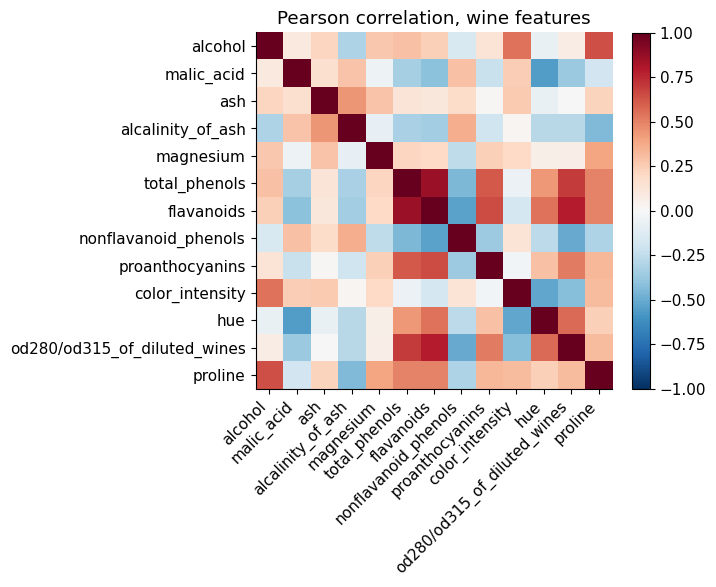


Top correlated feature pairs:
  total_phenols              vs  flavanoids                :  r = +0.86
  flavanoids                 vs  total_phenols             :  r = +0.86
  flavanoids                 vs  od280/od315_of_diluted_wines :  r = +0.79
  od280/od315_of_diluted_wines  vs  flavanoids                :  r = +0.79
  total_phenols              vs  od280/od315_of_diluted_wines :  r = +0.70
  od280/od315_of_diluted_wines  vs  total_phenols             :  r = +0.70


In [ ]:
corr = X.corr()
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr))); ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr))); ax.set_yticklabels(corr.columns)
plt.colorbar(im, ax=ax, fraction=0.045)
ax.set_title("Pearson correlation, wine features"); plt.tight_layout(); plt.show()

# Print the strongest off-diagonal pairs
absc = corr.abs().where(~np.eye(len(corr), dtype=bool))
pairs = absc.unstack().dropna().sort_values(ascending=False).head(6)
print("\nTop correlated feature pairs:")
for (a, b), v in pairs.items():
    print(f"  {a:25s}  vs  {b:25s} :  r = {corr.loc[a, b]:+.2f}")


## 5.  Exercise 4 — A Tiny Synthetic Galaxy Catalog

Now imagine a mini SDSS-style catalog with 4 columns.  Define it below
and inspect each column.


In [ ]:
galaxies = pd.DataFrame({
    "morphology":   ["spiral", "elliptical", "spiral", "irregular",
                     "elliptical", "spiral"],
    "image_quality":["OK",      "excellent",  "poor", "OK",
                     "excellent","OK"],
    "r_band_mag":   [18.7, 16.4, 20.1, 21.5, 17.8, 19.2],
    "redshift_z":   [0.12, 0.05, 0.28, 0.34, 0.09, 0.18],
})
galaxies


,morphology,image_quality,r_band_mag,redshift_z
0,spiral,OK,18.7,0.12
1,elliptical,excellent,16.4,0.05
2,spiral,poor,20.1,0.28
3,irregular,OK,21.5,0.34
4,elliptical,excellent,17.8,0.09
5,spiral,OK,19.2,0.18


**Your task.**  Decide the data type of each column:

| column          | type? |
|-----------------|-------|
| morphology      | ?     |
| image_quality   | ?     |
| r_band_mag      | ?     |
| redshift_z      | ?     |

<details>
<summary><b>Reveal answers</b></summary>

* `morphology`     — **Nominal**  (no inherent order)
* `image_quality`  — **Ordinal**  (poor < OK < excellent, but spacing not meaningful)
* `r_band_mag`     — **Interval** (differences meaningful, but no true zero)
* `redshift_z`     — **Ratio**    (z=0 is true zero)

</details>


## 6.  Exercise 5 — Reproduce the Curse-of-Dimensionality Curve

Lec 1b showed that the side length needed to capture a fraction `p` of
points in a `d`-dim unit cube grows as

$$\ell(d) = p^{1/d}$$

Plot this for `d = 1 … 25` and three values of `p`.


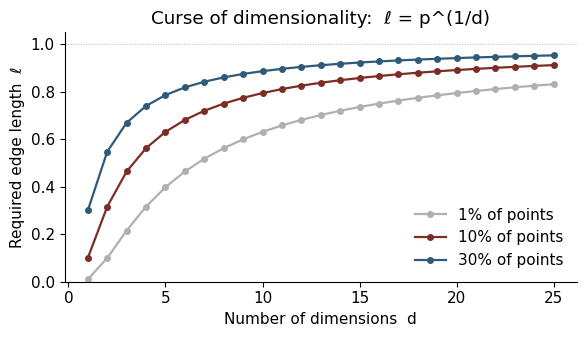

In [ ]:
d = np.arange(1, 26)
for p, label, color in [(0.01, "1% of points",  "#B0B0B0"),
                        (0.10, "10% of points", "#7B2D26"),
                        (0.30, "30% of points", "#2F5A7A")]:
    ell = p ** (1 / d)
    plt.plot(d, ell, "-o", ms=4, lw=1.6, color=color, label=label)

plt.axhline(1.0, color="#bbbbbb", lw=0.7, ls=":")
plt.xlabel("Number of dimensions  d")
plt.ylabel("Required edge length  ℓ")
plt.ylim(0, 1.05); plt.legend(frameon=False)
plt.title("Curse of dimensionality:  ℓ = p^(1/d)")
plt.tight_layout(); plt.show()


**Interpret the plot.**

* At `d = 1`, capturing 10% of points only needs `ℓ = 0.10`.
* At `d = 10`, the same 10% requires `ℓ ≈ 0.79`  — almost the whole cube.

This is why every Lec 1b–4 example is careful about how many features
to throw at a model with a fixed-size dataset.


## 7.  Wrap-Up

You just practiced:

1. Framing an ML problem  (Exercise 1)
2. Identifying data types  (Exercises 2 + 4)
3. EDA — shape, dtypes, distributions, correlations  (Exercise 3)
4. Visualizing the curse of dimensionality  (Exercise 5)

**For your own thesis data, repeat each of these steps before training
any model.**

---

**Next up:** Lecture 2 — Data Preparation (imputation, scaling,
encoding, dimensionality reduction).
